# ConvLSTM final — Etapa 3

**Qué cambia respecto al `convLSTM_3.ipynb` original:**
1. Lee de `input3/` (rasters con extent fijo, CRS EPSG:32614, celda 5x5m) en vez de `input2/`.
2. **Corrige un bug real** encontrado en el original: `sorted(glob.glob(...))` ordena los
   archivos alfabéticamente como texto, no cronológicamente (con meses sin cero a la
   izquierda, el orden real quedaba Ene, Oct, Nov, Dic, Feb, Mar... dentro de cada año).
   Aquí se ordena explícitamente por (año, mes) extraídos del nombre del archivo.
3. Arquitectura, hiperparámetros, split de datos y métricas: **exactamente los mismos que
   el original**

**Por qué no se cambia nada más todavía:** el objetivo de esta corrida es aislar el efecto
de (a) rasters bien alineados y (b) el fix del orden cronológico, contra el resultado ya
conocido (MAE 0.0918, RMSE 0.1147, IoU 0.0196, PAI 0.3843). Todo parámetro que no está
justificado en el repo original se deja igual, pero se marca con `# MEJORA:` para atacarlo
después si esta corrida no resuelve el problema por sí sola.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
 #Para comprobar el tipo de GPU asignada a nuestro portatil, utilizamos el siguiente comando.
!nvidia-smi

Fri Jul 24 18:08:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   62C    P0             29W /   70W |   13891MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# ============================================================================
# 1. CONFIGURACION Y PARAMETROS
# ============================================================================
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, Conv3D, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.ndimage import zoom
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import glob
import os
import re
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ======================================================
# OPTIMIZACION GPU PARA GOOGLE COLAB
# ======================================================
from tensorflow.keras import backend as K
K.clear_session()
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU configurada con memory growth habilitado")
    except RuntimeError as e:
        print(e)

GPU configurada con memory growth habilitado


## Parametros

Los que traen `# MEJORA:` son valores que el repo original usa **sin justificar por que**
(no hay un experimento de barrido de hiperparametros documentado que respalde estos
numeros especificos). Se dejan igual en esta corrida a proposito, para que la unica
variable que cambia sea el insumo (rasters), no la arquitectura. Quedan marcados para
una Etapa 4 de busqueda de hiperparametros si hace falta.

In [ ]:
# ======================================================
# PARAMETROS DE ENTRADA Y SALIDA
# ======================================================
print("\nConfigurando rutas de salida y entrada de datos ...")

# AJUSTA ESTAS DOS RUTAS a donde tengas tus carpetas en Drive:
ruta_rasters = '/content/drive/MyDrive/Raster_nuevo/kde_200_5m_*.tif'
ruta_salida = '/content/drive/MyDrive/salidas_v1_brd/'

target_shape = (90, 124) # soportado por colab
row, col = target_shape

# MEJORA: n_frames=12 (ventana de 1 anio) es razonable por estacionalidad, pero nunca se
# probo n_frames=6 o n_frames=24 para ver si cambia el desempeÑo.
n_frames = 12

test_size = 0.2
val_size = 0.1

# MEJORA: batch_size=11, epochs=50, num_capas=4 (y filters=37, dropout=0.3, l2=1e-4 mas
# abajo en crear_modelo_convlstm) no tienen una justificacion documentada en el repo
batch_size = 11
epochs = 50
num_capas = 4

# MEJORA: threshold_percentage=10 (top 10% de celdas = hotspot) pero tampoco se probo sensibilidad (5%, 15%, 20%) en el repo.
threshold_percentage = 10

os.makedirs(ruta_salida, exist_ok=True)
print("\nConfigurado OK")


Configurando rutas de salida y entrada de datos ...

Configurado OK


## Funciones auxiliares

`cargar_y_redimensionar_rasters` incluye el **fix del orden cronologico** (ver celda
siguiente): en vez de `sorted(glob.glob(...))` (orden alfabetico de texto), se extrae
`(year, month)` del nombre de cada archivo con una expresion regular y se ordena
numericamente. Esto aplica tanto para los nombres del raster nuevo
(`kde_200_5m_2018_1.tif`) como para el patron viejo (`kde_200_900_1024_2018_1.tif`) si
alguna vez necesitas volver a correr esto sobre `input2/`.

In [ ]:
# ============================================================================
# 2. FUNCIONES AUXILIARES
# ============================================================================

def extraer_year_month(nombre_archivo):
    '''Extrae (year, month) del nombre del archivo para poder ordenar
    cronologicamente en vez de alfabeticamente. Funciona con ambos patrones:
    kde_200_5m_2018_1.tif  o  kde_200_900_1024_2018_1.tif'''
    m = re.search(r'_(\d{4})_(\d{1,2})\.tif$', nombre_archivo)
    if not m:
        raise ValueError(f"No se pudo extraer year/month de: {nombre_archivo}")
    year, month = int(m.group(1)), int(m.group(2))
    return (year, month)


def cargar_y_redimensionar_rasters(ruta_rasters, target_shape):
    '''
    Carga y redimensiona las imagenes raster.

    FIX vs. el original: se ordena por (year, month) real extraido del nombre
    del archivo, NO con sorted() alfabetico (que mezclaba el orden: Ene, Oct,
    Nov, Dic, Feb, Mar... dentro de cada anio porque los meses no llevan cero
    a la izquierda).
    '''
    print("Cargando y redimensionando rasters...")
    rasters = glob.glob(ruta_rasters)
    if len(rasters) == 0:
        raise ValueError(f"No se encontraron archivos en la ruta: {ruta_rasters}")

    # --- FIX: orden cronologico real, no alfabetico ---
    rasters = sorted(rasters, key=extraer_year_month)

    # Verificacion rapida de que el orden quedo bien (primeros 15 archivos)
    print("Orden de los primeros archivos (verificar que sea cronologico):")
    for r in rasters[:15]:
        print(f"  {extraer_year_month(r)}  ->  {os.path.basename(r)}")

    sequences = []
    for i, raster in enumerate(rasters):
        try:
            with rasterio.open(raster) as src:
                image = src.read(1)
                zoom_factors = (target_shape[0] / image.shape[0], target_shape[1] / image.shape[1])
                resized_image = zoom(image, zoom_factors, order=1)
                sequences.append(resized_image)
        except Exception as e:
            print(f"Error procesando {raster}: {e}")
            continue

    sequences = np.array(sequences, dtype=np.float32)
    sequences = sequences / sequences.max()
    print(f"Cargadas {len(sequences)} imagenes de tamano {target_shape}")
    return sequences


def dividir_datos_temporales(sequences, test_size=0.2):
    '''Divide los datos manteniendo el orden temporal.'''
    n_total = len(sequences)
    n_test = int(n_total * test_size)
    train_sequences = sequences[:-n_test]
    test_sequences = sequences[-n_test:]
    print(f"Division temporal: {len(train_sequences)} para entrenamiento, {len(test_sequences)} para test")
    return train_sequences, test_sequences


def generar_secuencias(sequences, n_frames=12):
    '''Genera secuencias de entrada (X) y objetivo (y) para ConvLSTM.'''
    n_samples = sequences.shape[0] - n_frames
    if n_samples <= 0:
        raise ValueError(f"No hay suficientes frames. Se necesitan al menos {n_frames + 1} frames.")
    print(f'Generando {n_samples} secuencias de {n_frames} frames cada una')

    X = np.zeros((n_samples, n_frames, sequences.shape[1], sequences.shape[2], 1), dtype=np.float32)
    y = np.zeros((n_samples, n_frames, sequences.shape[1], sequences.shape[2], 1), dtype=np.float32)
    for i in range(n_samples):
        X[i, :, :, :, 0] = sequences[i:i + n_frames]
        y[i, :, :, :, 0] = sequences[i + 1:i + n_frames + 1]
    return X, y


def crear_modelo_convlstm(input_shape, num_capas=4):
    '''Crea el modelo ConvLSTM (misma arquitectura que el original, incluyendo
    BatchNormalization activa, que es como quedo en el bloque final del
    notebook original -- el de la prediccion autorregresiva de 12 meses).'''
    model = Sequential()
    for i in range(num_capas):
        return_sequences = True
        model.add(ConvLSTM2D(
            # MEJORA: filters=37, kernel_size=3x3, dropout=0.3, recurrent_dropout=0.3,
            # l2=1e-4 -- ninguno de estos numeros tiene una justificacion.
            filters=37,
            kernel_size=(3, 3),
            input_shape=input_shape if i == 0 else None,
            padding='same',
            return_sequences=return_sequences,
            dropout=0.3,
            recurrent_dropout=0.3,
            kernel_regularizer=l2(1e-4),
            recurrent_regularizer=l2(1e-4)
        ))
        if i < num_capas - 1:
            model.add(BatchNormalization())

    model.add(Conv3D(filters=1, kernel_size=(3, 3, 3), activation='sigmoid', padding='same'))
    return model

In [ ]:
# ============================================================================
# 3. CARGA Y PREPROCESAMIENTO
# ============================================================================
sequences = cargar_y_redimensionar_rasters(ruta_rasters, target_shape)
print(f"Tamano de la secuencia: {sequences.shape}")
print(f"Tipo de datos: {sequences.dtype}")
print("Configurando datos train y test")
train_sequences, test_sequences = dividir_datos_temporales(sequences, test_size)
X_train, y_train = generar_secuencias(train_sequences, n_frames)
X_test, y_test = generar_secuencias(test_sequences, n_frames)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

Cargando y redimensionando rasters...
Orden de los primeros archivos (verificar que sea cronologico):
  (2018, 1)  ->  kde_200_5m_2018_1.tif
  (2018, 2)  ->  kde_200_5m_2018_2.tif
  (2018, 3)  ->  kde_200_5m_2018_3.tif
  (2018, 4)  ->  kde_200_5m_2018_4.tif
  (2018, 5)  ->  kde_200_5m_2018_5.tif
  (2018, 6)  ->  kde_200_5m_2018_6.tif
  (2018, 7)  ->  kde_200_5m_2018_7.tif
  (2018, 8)  ->  kde_200_5m_2018_8.tif
  (2018, 9)  ->  kde_200_5m_2018_9.tif
  (2018, 10)  ->  kde_200_5m_2018_10.tif
  (2018, 11)  ->  kde_200_5m_2018_11.tif
  (2018, 12)  ->  kde_200_5m_2018_12.tif
  (2019, 1)  ->  kde_200_5m_2019_1.tif
  (2019, 2)  ->  kde_200_5m_2019_2.tif
  (2019, 3)  ->  kde_200_5m_2019_3.tif
Cargadas 72 imagenes de tamano (90, 124)
Tamano de la secuencia: (72, 90, 124)
Tipo de datos: float32
Configurando datos train y test
Division temporal: 58 para entrenamiento, 14 para test
Generando 46 secuencias de 12 frames cada una
Generando 2 secuencias de 12 frames cada una
X_train: (46, 12, 90, 124, 

In [ ]:
# ============================================================================
# 4. MODELO Y CALLBACKS
# ============================================================================
input_shape = (n_frames, row, col, 1)
model = crear_modelo_convlstm(input_shape, num_capas)

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),  # MEJORA: lr no barrido
              loss='mse',
              metrics=['mae'])

model.summary()

checkpoint_cb = ModelCheckpoint(
    filepath=os.path.join(ruta_salida, 'mejor_modelo.keras'),
    save_best_only=True,
    monitor='val_loss',
    mode='min',
    verbose=1
)
earlystop_cb = EarlyStopping(
    monitor='val_loss',
    patience=5,  # MEJORA: no justificado por que 5 y no 10 (el original usa ambos en distintas celdas)
    restore_best_weights=True,
    verbose=1
)
reduce_lr_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,  # MEJORA: idem, no justificado
    min_lr=1e-6,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 12, 90, 124,    │        50,764 │
│                                 │ 37)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12, 90, 124,    │           148 │
│ (BatchNormalization)            │ 37)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 12, 90, 124,    │        98,716 │
│                                 │ 37)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 90, 124,    │           148 │
│ (BatchNormalization)            │ 37)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_2 (ConvLSTM2D)      │ (None, 12, 90, 124,    │        98,716 │
│                                 │ 37)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 90, 124,    │           148 │
│ (BatchNormalization)            │ 37)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_3 (ConvLSTM2D)      │ (None, 12, 90, 124,    │        98,716 │
│                                 │ 37)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (None, 12, 90, 124, 1) │         1,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 348,356 (1.33 MB)

 Trainable params: 348,134 (1.33 MB)

 Non-trainable params: 222 (888.00 B)

In [ ]:
# ============================================================================
# 5. ENTRENAMIENTO
# ============================================================================
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=val_size,
    callbacks=[checkpoint_cb, earlystop_cb, reduce_lr_cb],
    verbose=2
)

Epoch 1/50

Epoch 1: val_loss improved from None to 0.25019, saving model to /content/drive/MyDrive/salidas_v1_brd/mejor_modelo.keras

Epoch 1: finished saving model to /content/drive/MyDrive/salidas_v1_brd/mejor_modelo.keras
4/4 - 73s - 18s/step - loss: 0.2489 - mae: 0.3996 - val_loss: 0.2502 - val_mae: 0.4079 - learning_rate: 1.0000e-04
Epoch 2/50

Epoch 2: val_loss improved from 0.25019 to 0.25000, saving model to /content/drive/MyDrive/salidas_v1_brd/mejor_modelo.keras

Epoch 2: finished saving model to /content/drive/MyDrive/salidas_v1_brd/mejor_modelo.keras
4/4 - 8s - 2s/step - loss: 0.2216 - mae: 0.3650 - val_loss: 0.2500 - val_mae: 0.4081 - learning_rate: 1.0000e-04
Epoch 3/50

Epoch 3: val_loss improved from 0.25000 to 0.24968, saving model to /content/drive/MyDrive/salidas_v1_brd/mejor_modelo.keras

Epoch 3: finished saving model to /content/drive/MyDrive/salidas_v1_brd/mejor_modelo.keras
4/4 - 8s - 2s/step - loss: 0.1926 - mae: 0.3208 - val_loss: 0.2497 - val_mae: 0.4081 - l

Modelo guardado correctamente en formato .h5 y .keras


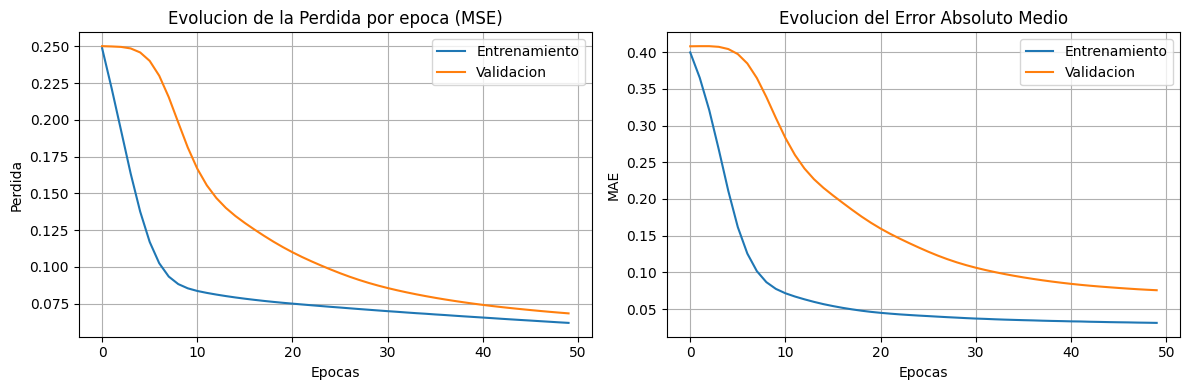

In [ ]:
# ============================================================================
# 6. GUARDADO Y VISUALIZACION
# ============================================================================
model.save(os.path.join(ruta_salida, 'modelo_final.h5'))
print("Modelo guardado correctamente en formato .h5 y .keras")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validacion')
plt.xlabel('Epocas'); plt.ylabel('Perdida')
plt.title('Evolucion de la Perdida por epoca (MSE)')
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Entrenamiento')
plt.plot(history.history['val_mae'], label='Validacion')
plt.xlabel('Epocas'); plt.ylabel('MAE')
plt.title('Evolucion del Error Absoluto Medio')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.savefig(f'{ruta_salida}entrenamiento_metricas.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================================
# 7. EVALUACION GLOBAL
# ============================================================================
print("Realizando predicciones en conjunto de prueba...")
y_pred = model.predict(X_test, verbose=1)

mae = mean_absolute_error(y_test.flatten(), y_pred.flatten())
rmse = np.sqrt(mean_squared_error(y_test.flatten(), y_pred.flatten()))
print(f"\nMAE global: {mae:.4f}")
print(f"RMSE global: {rmse:.4f}")

Realizando predicciones en conjunto de prueba...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step

MAE global: 0.0744
RMSE global: 0.0936


In [ ]:
# ============================================================================
# 8. METRICAS ESPACIALES (funciones)
# ============================================================================

def discretize_heatmap(heatmap, threshold_percentage):
    '''Convierte un mapa de calor continuo en un mapa binario de hotspots
    (top threshold_percentage% de celdas mas densas = 1).'''
    if not (0 < threshold_percentage <= 100):
        raise ValueError("El porcentaje del umbral debe estar entre 0 y 100.")
    threshold_value = np.percentile(heatmap, 100 - threshold_percentage)
    return (heatmap >= threshold_value).astype(int)


def calculate_iou(predicted_hotspots, true_hotspots):
    '''Intersection over Union entre dos mapas binarios de hotspots.'''
    intersection = np.sum((predicted_hotspots == 1) & (true_hotspots == 1))
    union = np.sum((predicted_hotspots == 1) | (true_hotspots == 1))
    if union == 0:
        return 1.0
    return intersection / union


def calculate_pai(predicted_hotspots, true_crime_locations):
    '''Predictive Accuracy Index = (%crimenes en hotspots) / (%area de hotspots).'''
    total_area = predicted_hotspots.size
    hotspot_area = np.sum(predicted_hotspots)
    if hotspot_area == 0:
        return 0.0
    percentage_area = hotspot_area / total_area
    total_crimes = len(true_crime_locations)
    if total_crimes == 0:
        return 0.0
    crimes_in_hotspots = 0
    for r, c in true_crime_locations:
        if 0 <= r < predicted_hotspots.shape[0] and 0 <= c < predicted_hotspots.shape[1]:
            if predicted_hotspots[r, c] == 1:
                crimes_in_hotspots += 1
    percentage_crimes = crimes_in_hotspots / total_crimes
    return percentage_crimes / percentage_area


print("Calculando metricas espaciales (un solo frame, igual que el original)...")
true_map = y_test[-1, -1, :, :, 0]
pred_map = y_pred[-1, -1, :, :, 0]

true_hotspots = discretize_heatmap(true_map, threshold_percentage)
pred_hotspots = discretize_heatmap(pred_map, threshold_percentage)

iou = calculate_iou(pred_hotspots, true_hotspots)
print(f"IoU (un frame): {iou:.4f}")

true_crime_locations = np.argwhere(true_hotspots == 1)
pai = calculate_pai(pred_hotspots, true_crime_locations)
print(f"PAI (un frame): {pai:.4f}")

Calculando metricas espaciales (un solo frame, igual que el original)...
IoU (un frame): 0.3053
PAI (un frame): 4.6774


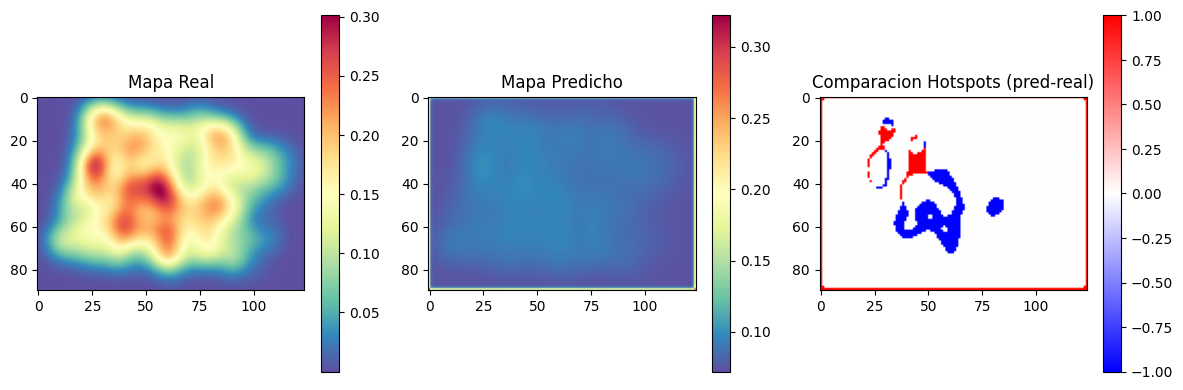

In [ ]:
# Visualizacion de comparacion (mismo bloque que el original)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(true_map, cmap='Spectral_r', vmin=np.min(true_map), vmax=np.max(true_map)); plt.title('Mapa Real')
plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(pred_map, cmap='Spectral_r', vmin=np.min(pred_map), vmax=np.max(pred_map)); plt.title('Mapa Predicho')
plt.colorbar()
plt.subplot(1,3,3)
plt.imshow(pred_hotspots - true_hotspots, cmap='bwr', vmin=-1, vmax=1)
plt.colorbar()
plt.title('Comparacion Hotspots (pred-real)')
plt.tight_layout()
plt.savefig(os.path.join(ruta_salida, '_map_real_predico_comparacion.png'), dpi=300, bbox_inches='tight')
plt.show()

## Prediccion autorregresiva de 12 meses

Igual que en el notebook original: se toma la ultima secuencia de test como punto de
partida, se predice un mes, se agrega al final de la ventana (descartando el mas
antiguo), y se repite 12 veces para simular un anio completo de pronostico.

In [ ]:
# ============================================================================
# 9. PREDICCION AUTORREGRESIVA DE 12 MESES (1 ANIO)
# ============================================================================
print("\nGenerando predicciones autorregresivas para 12 meses...")

track = X_test[-1].copy()  # shape (12, row, col, 1)
predicted_sequence = []

for j in range(12):
    new_pos = model.predict(track[np.newaxis, :, :, :, :], verbose=0)
    new_frame = new_pos[:, -1, :, :, :]
    predicted_sequence.append(new_frame[0])
    track = np.concatenate((track[1:], new_frame[0:1]), axis=0)

predicted_sequence = np.array(predicted_sequence)  # (12, row, col, 1)
print(f"Secuencia predicha con forma: {predicted_sequence.shape}")

for i in range(12):
    plt.figure(figsize=(6,4))
    plt.imshow(predicted_sequence[i, :, :, 0], cmap='Spectral_r',
               vmin=np.min(predicted_sequence), vmax=np.max(predicted_sequence))
    plt.title(f"Prediccion Mes {i+1}")
    plt.colorbar()
    plt.axis('off')
    plt.savefig(os.path.join(ruta_salida, f"prediccion_mes_{i+1}.png"), dpi=200, bbox_inches='tight')
    plt.close()


Generando predicciones autorregresivas para 12 meses...
Secuencia predicha con forma: (12, 90, 124, 1)



Calculando metricas espaciales para cada mes predicho...

Metricas promedio en 2 mes(es) disponibles:
IoU medio: 0.2882
PAI medio: 4.4668


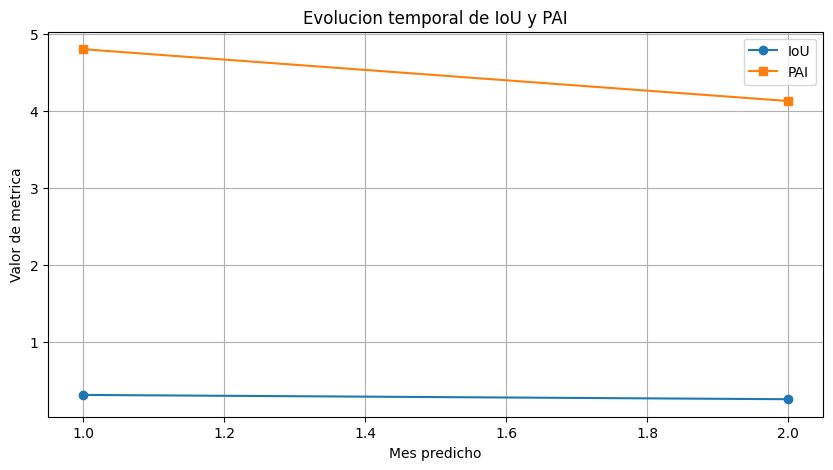

In [ ]:
# ============================================================================
# 10. METRICAS ESPACIALES -- EVALUACION TEMPORAL (12 meses)
# ============================================================================
print("\nCalculando metricas espaciales para cada mes predicho...")
ious, pais = [], []

for t in range(min(12, y_test.shape[0])):
    true_map_t = y_test[t, -1, :, :, 0]
    pred_map_t = predicted_sequence[t, :, :, 0]

    true_hotspots_t = discretize_heatmap(true_map_t, threshold_percentage)
    pred_hotspots_t = discretize_heatmap(pred_map_t, threshold_percentage)

    iou_t = calculate_iou(pred_hotspots_t, true_hotspots_t)
    ious.append(iou_t)

    true_crime_locations_t = np.argwhere(true_hotspots_t == 1)
    pai_t = calculate_pai(pred_hotspots_t, true_crime_locations_t)
    pais.append(pai_t)

iou_mean = np.mean(ious)
pai_mean = np.mean(pais)
print(f"\nMetricas promedio en {len(ious)} mes(es) disponibles:")
print(f"IoU medio: {iou_mean:.4f}")
print(f"PAI medio: {pai_mean:.4f}")

plt.figure(figsize=(10,5))
plt.plot(range(1, len(ious)+1), ious, marker='o', label='IoU')
plt.plot(range(1, len(pais)+1), pais, marker='s', label='PAI')
plt.title('Evolucion temporal de IoU y PAI')
plt.xlabel('Mes predicho')
plt.ylabel('Valor de metrica')
plt.legend(); plt.grid(True)
plt.savefig(os.path.join(ruta_salida, 'metricas_temporales.png'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================================
# 11. COMPARACION CONTRA EL RESULTADO ANTERIOR (rasters viejos, input2/)
# ============================================================================
resultado_anterior = {
    "MAE": 0.0918, "RMSE": 0.1147, "IoU": 0.0196, "PAI": 0.3843,
}
resultado_nuevo = {
    "MAE": mae, "RMSE": rmse, "IoU": iou_mean, "PAI": pai_mean,
}

print(f"{'Metrica':<10} {'Anterior (input2/)':<20} {'Nuevo (input3/)':<20}")
for k in resultado_anterior:
    print(f"{k:<10} {resultado_anterior[k]:<20.4f} {resultado_nuevo[k]:<20.4f}")

Metrica    Anterior (input2/)   Nuevo (input3/)     
MAE        0.0918               0.0744              
RMSE       0.1147               0.0936              
IoU        0.0196               0.2882              
PAI        0.3843               4.4668              


## Checklist de parametros pendientes de justificar/optimizar (Etapa 4)

Todo lo siguiente se dejo **igual al original a proposito** en esta corrida, para que la
unica variable fuera el insumo (rasters + fix de orden cronologico). Si el resultado de
arriba mejora poco, estos son los candidatos a atacar despues, en orden sugerido de
impacto probable:

1. **Tamano del test set** (~2 secuencias) -- la limitacion mas grave, cualquier metrica
   sobre 2 muestras es ruidosa. Candidato: mas datos, o validacion walk-forward en vez de
   un solo corte 80/20.
3. **num_capas=4, filters=37, kernel_size=3x3** -- sin barrido de hiperparametros documentado.
4. **dropout=0.3, recurrent_dropout=0.3, l2=1e-4** -- mismo caso.
5. **batch_size=11, epochs=50, learning_rate=1e-4** -- mismo caso.
6. **threshold_percentage=10** para discretizar hotspots -- convencion de la literatura,
   nunca se probo sensibilidad.
7. **n_frames=12** -- razonable por estacionalidad anual, pero no probado contra otras ventanas.